In [5]:
import polars as pl
from pathlib import Path

In [6]:
base_path = Path("data/t_ecd_small_partial/dataset/small")

retail_events_path = base_path / "retail" / "events"
lf_retail = pl.scan_parquet(str(retail_events_path / "*.pq"))

print("RETAIL EVENTS:")
print("Схема:", lf_retail.collect_schema())
print("Первые 5 строк:")
print(lf_retail.head(5).collect())

RETAIL EVENTS:
Схема: Schema({'timestamp': Duration(time_unit='us'), 'user_id': UInt64, 'item_id': String, 'subdomain': String, 'action_type': String, 'os': String})
Первые 5 строк:
shape: (5, 6)
┌────────────────┬──────────┬──────────────┬───────────┬─────────────┬─────────┐
│ timestamp      ┆ user_id  ┆ item_id      ┆ subdomain ┆ action_type ┆ os      │
│ ---            ┆ ---      ┆ ---          ┆ ---       ┆ ---         ┆ ---     │
│ duration[μs]   ┆ u64      ┆ str          ┆ str       ┆ str         ┆ str     │
╞════════════════╪══════════╪══════════════╪═══════════╪═════════════╪═════════╡
│ 1200d 98323µs  ┆ 43251046 ┆ fmcg_540829  ┆ catalog   ┆ view        ┆ android │
│ 1200d 274719µs ┆ 29072621 ┆ fmcg_1154479 ┆ catalog   ┆ view        ┆ android │
│ 1200d 404436µs ┆ 79876302 ┆ fmcg_177643  ┆ catalog   ┆ view        ┆ android │
│ 1200d 432255µs ┆ 76238048 ┆ fmcg_675142  ┆ catalog   ┆ view        ┆ android │
│ 1200d 523532µs ┆ 40098575 ┆ fmcg_696068  ┆ catalog   ┆ view        ┆ andr

In [7]:
marketplace_events_path = base_path / "marketplace" / "events"
lf_marketplace = pl.scan_parquet(str(marketplace_events_path / "*.pq"))

print("MARKETPLACE EVENTS:")
print("Схема:", lf_marketplace.collect_schema())
print("\nПервые 5 строк:")
print(lf_marketplace.head(5).collect())

MARKETPLACE EVENTS:
Схема: Schema({'timestamp': Duration(time_unit='us'), 'user_id': UInt64, 'item_id': String, 'subdomain': String, 'action_type': String, 'os': String})

Первые 5 строк:
shape: (5, 6)
┌───────────────────┬──────────┬────────────────┬───────────┬─────────────┬─────────┐
│ timestamp         ┆ user_id  ┆ item_id        ┆ subdomain ┆ action_type ┆ os      │
│ ---               ┆ ---      ┆ ---            ┆ ---       ┆ ---         ┆ ---     │
│ duration[μs]      ┆ u64      ┆ str            ┆ str       ┆ str         ┆ str     │
╞═══════════════════╪══════════╪════════════════╪═══════════╪═════════════╪═════════╡
│ 1200d 222299µs    ┆ 20322221 ┆ nfmcg_18961369 ┆ u2i       ┆ view        ┆ ios     │
│ 1200d 422277µs    ┆ 26590935 ┆ nfmcg_10940040 ┆ search    ┆ view        ┆ ios     │
│ 1200d 815192µs    ┆ 25438056 ┆ nfmcg_3329926  ┆ other     ┆ view        ┆ android │
│ 1200d 1s 243709µs ┆ 12366330 ┆ nfmcg_28252252 ┆ catalog   ┆ view        ┆ ios     │
│ 1200d 1s 582237µs ┆ 19

In [8]:
retail_events_path = base_path / "retail" / "events"
lf_retail = pl.scan_parquet(str(retail_events_path / "*.pq"))

print("СТАТИСТИКА RETAIL:")
stats_retail = (
    lf_retail
    .select([
        pl.len().alias("total_rows"),
        pl.col("user_id").n_unique().alias("unique_users"),
        pl.col("item_id").n_unique().alias("unique_items"),
        pl.col("action_type").n_unique().alias("action_types"),
        pl.col("subdomain").n_unique().alias("subdomains"),
        pl.col("os").n_unique().alias("os_types"),
    ])
    .collect()
)
print(stats_retail)

print("СТАТИСТИКА MARKETPLACE:")
stats_mp = (
    lf_marketplace
    .select([
        pl.len().alias("total_rows"),
        pl.col("user_id").n_unique().alias("unique_users"),
        pl.col("item_id").n_unique().alias("unique_items"),
        pl.col("action_type").n_unique().alias("action_types"),
        pl.col("subdomain").n_unique().alias("subdomains"),
        pl.col("os").n_unique().alias("os_types"),
    ])
    .collect()
)
print(stats_mp)


СТАТИСТИКА RETAIL:
shape: (1, 6)
┌────────────┬──────────────┬──────────────┬──────────────┬────────────┬──────────┐
│ total_rows ┆ unique_users ┆ unique_items ┆ action_types ┆ subdomains ┆ os_types │
│ ---        ┆ ---          ┆ ---          ┆ ---          ┆ ---        ┆ ---      │
│ u32        ┆ u32          ┆ u32          ┆ u32          ┆ u32        ┆ u32      │
╞════════════╪══════════════╪══════════════╪══════════════╪════════════╪══════════╡
│ 177064648  ┆ 87424        ┆ 231616       ┆ 3            ┆ 5          ┆ 2        │
└────────────┴──────────────┴──────────────┴──────────────┴────────────┴──────────┘
СТАТИСТИКА MARKETPLACE:
shape: (1, 6)
┌────────────┬──────────────┬──────────────┬──────────────┬────────────┬──────────┐
│ total_rows ┆ unique_users ┆ unique_items ┆ action_types ┆ subdomains ┆ os_types │
│ ---        ┆ ---          ┆ ---          ┆ ---          ┆ ---        ┆ ---      │
│ u32        ┆ u32          ┆ u32          ┆ u32          ┆ u32        ┆ u32      │
╞════

In [9]:
retail_actions = (
    lf_retail
    .group_by(["action_type", "subdomain"])
    .agg([
        pl.count().alias("count")
    ])
    .sort(["action_type", "count"], descending=[False, True])
    .collect()
)
print(retail_actions.head(20))

/tmp/ipykernel_96079/2951963631.py:5: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("count")


shape: (15, 3)
┌───────────────┬───────────┬───────────┐
│ action_type   ┆ subdomain ┆ count     │
│ ---           ┆ ---       ┆ ---       │
│ str           ┆ str       ┆ u32       │
╞═══════════════╪═══════════╪═══════════╡
│ added-to-cart ┆ search    ┆ 959536    │
│ added-to-cart ┆ catalog   ┆ 801998    │
│ added-to-cart ┆ item      ┆ 334926    │
│ added-to-cart ┆ main      ┆ 307882    │
│ added-to-cart ┆ cart      ┆ 83699     │
│ …             ┆ …         ┆ …         │
│ view          ┆ catalog   ┆ 155384822 │
│ view          ┆ search    ┆ 13929076  │
│ view          ┆ main      ┆ 2168073   │
│ view          ┆ item      ┆ 1079843   │
│ view          ┆ cart      ┆ 547412    │
└───────────────┴───────────┴───────────┘


In [10]:
# 1. Воронка по action_type (общая конверсия)
print("Воронка retail (по action_type):")
funnel_retail = (
    lf_retail
    .group_by("action_type")
    .agg([pl.count().alias("count")])
    .sort("count", descending=True)
    .collect()
)
print(funnel_retail)

# Конверсия view → add_to_cart → order
print("Конверсия (примерная):")
total_views = funnel_retail.filter(pl.col("action_type") == "view")["count"][0]
total_carts = funnel_retail.filter(pl.col("action_type") == "add_to_cart")["count"][0] if len(funnel_retail.filter(pl.col("action_type") == "add_to_cart")) > 0 else 0
total_orders = funnel_retail.filter(pl.col("action_type") == "order")["count"][0] if len(funnel_retail.filter(pl.col("action_type") == "order")) > 0 else 0
print(f"View → Cart: {total_carts/total_views*100:.1f}%")
print(f"View → Order: {total_orders/total_views*100:.1f}%")


Воронка retail (по action_type):


/tmp/ipykernel_96079/3179957694.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias("count")])


shape: (3, 2)
┌───────────────┬───────────┐
│ action_type   ┆ count     │
│ ---           ┆ ---       │
│ str           ┆ u32       │
╞═══════════════╪═══════════╡
│ view          ┆ 173109226 │
│ added-to-cart ┆ 2488041   │
│ click         ┆ 1467381   │
└───────────────┴───────────┘
Конверсия (примерная):
View → Cart: 0.0%
View → Order: 0.0%


In [11]:
# 2. ОС (top-5)
print("ОС:")
os_stats = (
    lf_retail
    .group_by("os")
    .agg([pl.count().alias("count")])
    .sort("count", descending=True)
    .head(5)
    .collect()
)
print(os_stats)

# 3. Топ-10 активных пользователей
print("Топ-10 активных пользователей:")
user_activity = (
    lf_retail
    .group_by("user_id")
    .agg([
        pl.count().alias("events"),
        pl.col("action_type").n_unique().alias("action_types"),
        pl.col("subdomain").n_unique().alias("subdomains")
    ])
    .sort("events", descending=True)
    .head(10)
    .collect()
)
print(user_activity)


ОС:


/tmp/ipykernel_96079/404274975.py:6: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias("count")])


shape: (2, 2)
┌─────────┬───────────┐
│ os      ┆ count     │
│ ---     ┆ ---       │
│ str     ┆ u32       │
╞═════════╪═══════════╡
│ android ┆ 160694316 │
│ ios     ┆ 16370332  │
└─────────┴───────────┘
Топ-10 активных пользователей:


/tmp/ipykernel_96079/404274975.py:19: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("events"),


shape: (10, 4)
┌──────────┬────────┬──────────────┬────────────┐
│ user_id  ┆ events ┆ action_types ┆ subdomains │
│ ---      ┆ ---    ┆ ---          ┆ ---        │
│ u64      ┆ u32    ┆ u32          ┆ u32        │
╞══════════╪════════╪══════════════╪════════════╡
│ 41892914 ┆ 84047  ┆ 3            ┆ 3          │
│ 42256527 ┆ 83650  ┆ 3            ┆ 5          │
│ 59615055 ┆ 83418  ┆ 3            ┆ 5          │
│ 38012265 ┆ 82952  ┆ 3            ┆ 5          │
│ 43861147 ┆ 82881  ┆ 3            ┆ 5          │
│ 49971543 ┆ 82627  ┆ 3            ┆ 5          │
│ 3502350  ┆ 82395  ┆ 3            ┆ 5          │
│ 75133255 ┆ 81756  ┆ 3            ┆ 5          │
│ 55807727 ┆ 81633  ┆ 3            ┆ 3          │
│ 70337518 ┆ 81526  ┆ 3            ┆ 5          │
└──────────┴────────┴──────────────┴────────────┘


In [12]:

# 4. Топ-10 товаров по просмотрам
print("Топ-10 товаров (просмотры):")
top_items = (
    lf_retail
    .filter(pl.col("action_type") == "view")
    .group_by("item_id")
    .agg([pl.count().alias("views")])
    .sort("views", descending=True)
    .head(10)
    .collect()
)
print(top_items)

# 5. Активные subdomains (top-5)
print("Активные subdomains (top-5):")
subdomains = (
    lf_retail
    .group_by("subdomain")
    .agg([pl.count().alias("events")])
    .sort("events", descending=True)
    .head(5)
    .collect()
)
print(subdomains)

# 6. Уникальность (сколько уникальных сущностей)
print("Размеры данных:")
sizes = (
    lf_retail
    .select([
        pl.count().alias("total_events"),
        pl.col("user_id").n_unique().alias("unique_users"),
        pl.col("item_id").n_unique().alias("unique_items"),
        pl.col("subdomain").n_unique().alias("unique_subdomains"),
        pl.col("os").n_unique().alias("unique_os")
    ])
    .collect()
)
print(sizes)

# 7. Математическая статистика (price если есть)
try:
    price_stats = (
        lf_retail
        .select([
            pl.col("price").mean().round(2).alias("avg_price"),
            pl.col("price").median().alias("median_price"),
            pl.col("price").min().alias("min_price"),
            pl.col("price").max().alias("max_price"),
        ])
        .collect()
    )
    print("Цены:")
    print(price_stats)
except:
    print("Колонка price отсутствует")


Топ-10 товаров (просмотры):


/tmp/ipykernel_96079/1140534350.py:7: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias("views")])


shape: (10, 2)
┌──────────────┬────────┐
│ item_id      ┆ views  │
│ ---          ┆ ---    │
│ str          ┆ u32    │
╞══════════════╪════════╡
│ fmcg_651828  ┆ 101626 │
│ fmcg_250877  ┆ 101546 │
│ fmcg_292617  ┆ 93370  │
│ fmcg_514296  ┆ 87692  │
│ fmcg_331271  ┆ 83795  │
│ fmcg_618591  ┆ 82373  │
│ fmcg_421212  ┆ 78304  │
│ fmcg_450490  ┆ 76303  │
│ fmcg_97712   ┆ 74090  │
│ fmcg_1047118 ┆ 73315  │
└──────────────┴────────┘
Активные subdomains (top-5):


/tmp/ipykernel_96079/1140534350.py:19: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  .agg([pl.count().alias("events")])


shape: (5, 2)
┌───────────┬───────────┐
│ subdomain ┆ events    │
│ ---       ┆ ---       │
│ str       ┆ u32       │
╞═══════════╪═══════════╡
│ catalog   ┆ 156717261 │
│ search    ┆ 15545834  │
│ main      ┆ 2554070   │
│ item      ┆ 1513775   │
│ cart      ┆ 733708    │
└───────────┴───────────┘
Размеры данных:


/tmp/ipykernel_96079/1140534350.py:31: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total_events"),


shape: (1, 5)
┌──────────────┬──────────────┬──────────────┬───────────────────┬───────────┐
│ total_events ┆ unique_users ┆ unique_items ┆ unique_subdomains ┆ unique_os │
│ ---          ┆ ---          ┆ ---          ┆ ---               ┆ ---       │
│ u32          ┆ u32          ┆ u32          ┆ u32               ┆ u32       │
╞══════════════╪══════════════╪══════════════╪═══════════════════╪═══════════╡
│ 177064648    ┆ 87424        ┆ 231616       ┆ 5                 ┆ 2         │
└──────────────┴──────────────┴──────────────┴───────────────────┴───────────┘
Колонка price отсутствует


In [13]:
features_path = Path("features")
features_path.mkdir(exist_ok=True)

# 1. User features (кроссдомен)
lf_retail_d = lf_retail.with_columns(pl.lit("retail").alias("domain"))
lf_mp_d = lf_marketplace.with_columns(pl.lit("marketplace").alias("domain"))

user_feats = (
    pl.concat([lf_retail_d, lf_mp_d])
    .group_by("user_id")
    .agg([
        pl.count().alias("total_events"),
        pl.col("domain").n_unique().alias("domains_used"),
        pl.col("action_type").n_unique().alias("action_types"),
        pl.col("item_id").n_unique().alias("unique_items")
    ])
)
user_feats.sink_parquet(str(features_path / "user_features.parquet"))

# 2. Item popularity
item_pop = (
    pl.concat([lf_retail, lf_marketplace])
    .group_by("item_id")
    .agg([
        pl.count().alias("events"),
        pl.col("user_id").n_unique().alias("users")
    ])
)
item_pop.sink_parquet(str(features_path / "item_popularity.parquet"))


/tmp/ipykernel_96079/1935137108.py:12: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("total_events"),
/tmp/ipykernel_96079/1935137108.py:25: DeprecationWarning: `pl.count()` is deprecated. Please use `pl.len()` instead.
(Deprecated in version 0.20.5)
  pl.count().alias("events"),


In [14]:
# Загружаем фичи целиком
users = pl.read_parquet("features/user_features.parquet")
items = pl.read_parquet("features/item_popularity.parquet")
users_sp = pl.read_parquet("data/t_ecd_small_partial/dataset/small/users.pq")
brands_sp = pl.read_parquet("data/t_ecd_small_partial/dataset/small/brands.pq")

# Cross-domain анализ
cross_domain_users = users.filter(pl.col("domains_used") == 2)
print(f"Cross-domain: {cross_domain_users.height} из {users.height}")

# Топ пользователи/товары
print(users.sort("total_events", descending=True).head(10))
print(items.sort("events", descending=True).head(10))


Cross-domain: 52945 из 551587
shape: (10, 5)
┌──────────┬──────────────┬──────────────┬──────────────┬──────────────┐
│ user_id  ┆ total_events ┆ domains_used ┆ action_types ┆ unique_items │
│ ---      ┆ ---          ┆ ---          ┆ ---          ┆ ---          │
│ u64      ┆ u32          ┆ u32          ┆ u32          ┆ u32          │
╞══════════╪══════════════╪══════════════╪══════════════╪══════════════╡
│ 41892914 ┆ 84154        ┆ 2            ┆ 4            ┆ 4168         │
│ 42256527 ┆ 83650        ┆ 1            ┆ 3            ┆ 6759         │
│ 59615055 ┆ 83422        ┆ 2            ┆ 3            ┆ 4919         │
│ 38012265 ┆ 82954        ┆ 2            ┆ 3            ┆ 6709         │
│ 43861147 ┆ 82881        ┆ 1            ┆ 3            ┆ 7111         │
│ 49971543 ┆ 82627        ┆ 1            ┆ 3            ┆ 4634         │
│ 3502350  ┆ 82396        ┆ 2            ┆ 3            ┆ 6426         │
│ 75133255 ┆ 81764        ┆ 2            ┆ 3            ┆ 5048         │
│ 5580

In [15]:
import pandas as pd
from sklearn.preprocessing import StandardScaler
from sklearn.cluster import KMeans
import matplotlib.pyplot as plt
from sklearn.decomposition import PCA


In [ ]:
user_feats = pl.read_parquet("features/user_features.parquet").to_pandas()

X = user_feats.drop(columns=["user_id"])
X = X.fillna(0)
scaler = StandardScaler()
X_scaled = scaler.fit_transform(X)


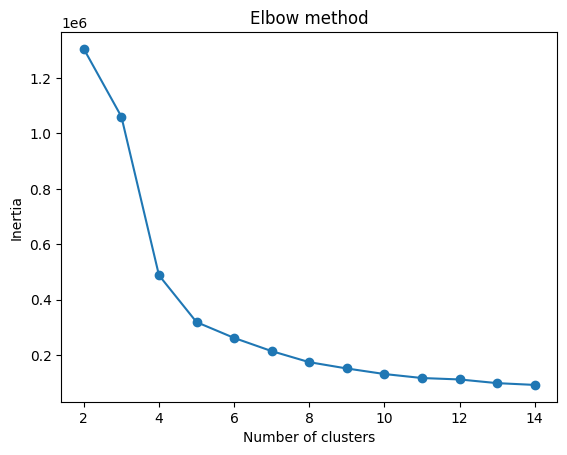

              user_id  total_events  domains_used  action_types  unique_items
cluster                                                                      
0        4.504289e+07    162.654143      1.000000      2.240220     67.291716
1        4.495292e+07     13.605497      1.000000      1.000000      8.864380
2        4.515948e+07   6362.773398      1.733483      3.005756   1430.471597
3        4.499922e+07    215.470466      2.000000      1.668289     66.000984
4        4.611689e+07  53714.667497      1.749689      3.014944   4447.388543
5        4.611666e+07  22570.984629      1.722459      3.001281   2793.668659
6        4.497616e+07    596.233918      2.000000      3.056442    224.755631


In [ ]:
inertia = []
k_range = range(2, 15)
for k in k_range:
    km = KMeans(n_clusters=k, random_state=42)
    km.fit(X_scaled)
    inertia.append(km.inertia_)

plt.plot(k_range, inertia, marker='o')
plt.title("Elbow method")
plt.xlabel("Number of clusters")
plt.ylabel("Inertia")
plt.show()

k = 7
km = KMeans(n_clusters=k, random_state=42)
user_feats["cluster"] = km.fit_predict(X_scaled)

print(user_feats.groupby("cluster").mean())
